# LangGraph QuickStart

LangGraph는 상태 기반 멀티 액터 애플리케이션을 구축하기 위한 프레임워크입니다.

## 구현 기능

- 상태 관리 기반 챗봇
- 외부 도구 연동 (Tavily Search)
- 메모리 및 체크포인트
- Human-in-the-Loop
- 상태 커스터마이징
- 상태 이력 관리

## 환경 설정

LangGraph를 사용하기 위해 필요한 환경 변수와 로깅을 설정합니다. `.env` 파일에 API 키를 저장하고, LangSmith를 통해 실행 과정을 추적할 수 있습니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangChain-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-V1-Tutorial


---

## 기본 챗봇 구축

메시지 기반 챗봇을 StateGraph로 구성합니다. StateGraph는 LangGraph의 핵심 구성 요소로, 노드와 엣지를 연결하여 상태 기반 워크플로우를 정의합니다.

> 📖 **참고 문서**: [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api.md)

### 구성 요소

| 구성 요소 | 설명 |
|----------|------|
| StateGraph | 전체 워크플로우 흐름을 정의하는 그래프 |
| State | 그래프 실행 중 데이터를 저장하는 상태 객체 |
| Node | 실제 작업을 수행하는 함수 (예: LLM 호출) |
| Edge | 노드 간 실행 경로를 연결 |
| Compile/Invoke | 그래프를 실행 가능한 형태로 변환 및 호출 |

아래 코드는 State 타입을 정의하고 StateGraph 인스턴스를 생성합니다.

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의: 챗봇의 상태를 나타내는 타입
class State(TypedDict):
    """챗봇의 상태를 정의하는 타입

    messages: 대화 메시지 리스트
    - add_messages 함수를 통해 새 메시지가 추가됨 (덮어쓰기가 아닌 추가)
    """

    messages: Annotated[list, add_messages]


# StateGraph 생성
graph_builder = StateGraph(State)

print("StateGraph 생성 완료!")
print("State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.")

StateGraph 생성 완료!
State는 messages 키를 가지며, add_messages 리듀서를 사용합니다.


### LLM 설정

LangGraph의 노드에서 사용할 언어 모델을 설정합니다. `init_chat_model` 함수를 사용하면 다양한 제공자(OpenAI, Anthropic 등)의 모델을 통일된 인터페이스로 사용할 수 있습니다.

아래 코드는 Anthropic의 Claude Sonnet 4.5 모델을 초기화합니다.

In [4]:
from langchain.chat_models import init_chat_model

# 모델 식별자 문자열을 사용한 간단한 방법
llm = init_chat_model("anthropic:claude-sonnet-4-5")

### 챗봇 노드 추가

노드는 그래프에서 실제 작업을 수행하는 함수입니다. 챗봇 노드는 현재 상태의 메시지를 받아 LLM에 전달하고, 응답을 새 메시지로 추가하여 반환합니다.

`add_node` 메서드의 첫 번째 인자는 노드의 고유 이름이고, 두 번째 인자는 호출될 함수입니다.

아래 코드는 챗봇 노드 함수를 정의하고 그래프에 추가합니다.

In [5]:
def chatbot(state: State):
    """챗봇 노드 함수

    현재 상태의 메시지를 받아 LLM에 전달하고,
    응답을 새 메시지로 추가하여 반환합니다.
    """
    # LLM을 호출하여 응답 생성
    response = llm.invoke(state["messages"])

    # 응답을 메시지 리스트에 추가하여 반환
    return {"messages": [response]}


# 그래프에 노드 추가
# 첫 번째 인자: 노드의 고유 이름
# 두 번째 인자: 노드가 사용될 때 호출될 함수
graph_builder.add_node("chatbot", chatbot)

### 엣지 설정

엣지는 노드 간의 실행 흐름을 정의합니다. `START`는 그래프 실행의 시작점이고, `END`는 종료점입니다. 모든 그래프는 반드시 시작점과 종료점을 가져야 합니다.

아래 코드는 실행 경로(START → chatbot → END)를 설정합니다.

In [6]:
# 진입점: 그래프 실행이 시작되는 지점
graph_builder.add_edge(START, "chatbot")

# 종료점: 그래프 실행이 끝나는 지점
graph_builder.add_edge("chatbot", END)

print("진입점과 종료점 설정 완료!")
print("실행 흐름: START → chatbot → END")

진입점과 종료점 설정 완료!
실행 흐름: START → chatbot → END


### 그래프 컴파일

StateGraph를 정의한 후에는 반드시 `compile()` 메서드를 호출하여 실행 가능한 형태로 변환해야 합니다. 컴파일 과정에서 노드 간 연결이 검증되고, 실행 순서가 결정됩니다.

아래 코드는 정의한 그래프를 컴파일하고 실행 가능한 객체를 반환합니다.

In [7]:
# 그래프 컴파일
graph = graph_builder.compile()

print("그래프 컴파일 완료!")

그래프 컴파일 완료!


### 그래프 시각화

컴파일된 그래프의 구조를 시각적으로 확인할 수 있습니다. `langchain_teddynote` 패키지의 `visualize_graph` 함수를 사용하면 노드와 엣지의 연결 상태를 한눈에 파악할 수 있습니다.

아래 코드는 컴파일된 그래프를 시각화합니다.

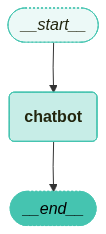

In [8]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph)

### 그래프 실행

`stream_graph` 함수를 사용하면 그래프 실행 결과를 스트리밍 방식으로 출력할 수 있습니다. `RunnableConfig`를 통해 재귀 깊이 제한(`recursion_limit`)과 스레드 식별자(`thread_id`)를 설정합니다.

아래 코드는 Config를 설정하고 사용자 입력을 준비합니다.

In [9]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage

# Config 설정(recursion_limit: 재귀 깊이 제한, thread_id: 스레드 아이디)
config = RunnableConfig(recursion_limit=20, thread_id="abc123")

In [10]:
inputs = {
    "messages": [HumanMessage(content="안녕하세요! LangGraph에 대해 알려주세요.")]
}

inputs = {
    "messages": ["안녕하세요! LangGraph에 대해 알려주세요."]
}

# 그래프 스트리밍
stream_graph(graph, inputs=inputs, config=config)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# LangGraph 소개

안녕하세요! LangGraph에 대해 설명해드리겠습니다.

## LangGraph란?

**LangGraph**는 LangChain 팀이 개발한 라이브러리로, **상태를 가진 다중 행위자(multi-actor) AI 애플리케이션을 그래프 구조로 구축**할 수 있게 해주는 프레임워크입니다.

## 주요 특징

### 1. **순환 그래프(Cyclic Graphs)**
- 일반적인 DAG(방향성 비순환 그래프)를 넘어 순환 구조 지원
- 에이전트가 반복적으로 작업을 수행할 수 있음

### 2. **상태 관리(State Management)**
- 각 노드 간 공유되는 상태를 명확하게 관리
- 대화 기록, 중간 결과 등을 체계적으로 유지

### 3. **제어 흐름(Control Flow)**
- 조건부 분기(conditional edges)
- 사람의 개입(human-in-the-loop) 지원
- 체크포인트 및 타임 트래블 기능

## 주요 사용 사례

- 🤖 **복잡한 AI 에이전트** 구축
- 💬 **대화형 챗봇** (멀티턴 대화)
- 🔄 **워크플로우 자동화**
- 🧠 **다중 에이전트 협업 시스템**

## 기본 구조

```python
from langgraph.graph import StateGraph

# 상태 정의
class State(TypedDict):
    messages: list[str]

# 그래프 생성
workflow = StateGraph(State)
workflow.add_node("node1", function1)
workflow.add_node("node2", function2)
workflow.add_edge("node1", "node2")
```

LangGraph에 대해 더 구체적으로 알고 싶은 부분이 있으신가요?

---

## 도구(Tools) 추가

외부 검색 도구를 통합하여 실시간 정보를 조회할 수 있는 챗봇을 만듭니다. LangGraph는 LLM이 외부 도구를 호출하고 그 결과를 활용하는 워크플로우를 쉽게 구성할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Tool Integration](https://docs.langchain.com/oss/python/langgraph/tool-integration.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Tool Binding | LLM에 사용 가능한 도구를 연결하는 과정 |
| Tool Node | 실제 외부 API를 호출하는 노드 |
| Conditional Edges | LLM 응답에 따라 도구 사용 여부를 자동 분기 |

아래 코드는 간단한 덧셈 도구를 정의합니다.

In [11]:
# 공유
from langchain_core.tools import tool


@tool
def add(a: int, b: int):
    "두 숫자를 더합니다."
    return a + b

In [12]:
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode, tools_condition

# Tavily 검색 도구 설정
tool = TavilySearch(max_results=2)
tools = [tool, add]

# 도구 테스트
result = tool.invoke("LangGraph란 무엇인가요?")
print(f"검색 결과 수: {len(result['results'])}개")
print(f"첫 번째 결과 제목: {result['results'][0]['title']}")

검색 결과 수: 2개
첫 번째 결과 제목: 1-1. 랭그래프 LangGraph 소개 - 위키독스


### 도구 사용 그래프 구성

기본 챗봇 흐름에 도구 호출 경로를 추가합니다. LLM이 도구 호출을 요청하면 "tools" 노드로 이동하고, 도구 실행 후 다시 챗봇으로 돌아오는 순환 구조(chatbot ⇄ tools)를 구성합니다.

아래 코드는 LLM에 도구를 바인딩합니다.

In [13]:
llm_with_tools = llm.bind_tools(tools)

In [14]:
ret1 = llm_with_tools.invoke("LangGraph 가 뭐야?")
ret2 = llm_with_tools.invoke("LangGraph 가 뭐야? 검색해서 알려줘")

In [15]:
print(ret1.content)

[{'id': 'toolu_011u7svLCAzPMi2vsvuzG3ko', 'caller': {'type': 'direct'}, 'input': {'query': 'LangGraph', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}]


In [16]:
from langchain_teddynote.messages import display_message_tree

display_message_tree(ret1)

    content:
        index [0]
            id: "toolu_011u7svLCAzPMi2vsvuzG3ko"
            caller: {"type": "direct"}
            input: {"query": "LangGraph", "search_depth": "advanced"}
            name: "tavily_search"
            type: "tool_use"
    additional_kwargs: {}
    response_metadata:
        id: "msg_01Rvds5on339n1w96Jps55Vd"
        container: None
        model: "claude-sonnet-4-5-20250929"
        stop_reason: "tool_use"
        stop_sequence: None
        usage:
            cache_creation: {"ephemeral_1h_input_tokens": 0, "ephemeral_5m_input_tokens": 0}
            cache_creation_input_tokens: 0
            cache_read_input_tokens: 0
            inference_geo: "not_available"
            input_tokens: 2286
            output_tokens: 75
            server_tool_use: None
            service_tier: "standard"
        stop_details: None
        model_name: "claude-sonnet-4-5-20250929"
        model_provider: "anthropic"
    type: "ai"
    name: None
    id: "lc_run--019e

In [17]:
display_message_tree(ret2)

    content:
        index [0]
            id: "toolu_013bARomPkiTmgSYBmGvULhU"
            caller: {"type": "direct"}
            input: {"query": "LangGraph", "search_depth": "advanced"}
            name: "tavily_search"
            type: "tool_use"
    additional_kwargs: {}
    response_metadata:
        id: "msg_01MK3GzdPbZX62QJdXcto3NA"
        container: None
        model: "claude-sonnet-4-5-20250929"
        stop_reason: "tool_use"
        stop_sequence: None
        usage:
            cache_creation: {"ephemeral_1h_input_tokens": 0, "ephemeral_5m_input_tokens": 0}
            cache_creation_input_tokens: 0
            cache_read_input_tokens: 0
            inference_geo: "not_available"
            input_tokens: 2296
            output_tokens: 75
            server_tool_use: None
            service_tier: "standard"
        stop_details: None
        model_name: "claude-sonnet-4-5-20250929"
        model_provider: "anthropic"
    type: "ai"
    name: None
    id: "lc_run--019e

In [19]:
ret2

AIMessage(content=[{'id': 'toolu_013bARomPkiTmgSYBmGvULhU', 'caller': {'type': 'direct'}, 'input': {'query': 'LangGraph', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01MK3GzdPbZX62QJdXcto3NA', 'container': None, 'model': 'claude-sonnet-4-5-20250929', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 2296, 'output_tokens': 75, 'server_tool_use': None, 'service_tier': 'standard'}, 'stop_details': None, 'model_name': 'claude-sonnet-4-5-20250929', 'model_provider': 'anthropic'}, id='lc_run--019e19de-8338-7e82-bffd-007a1c316133-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'LangGraph', 'search_depth': 'advanced'}, 'id': 'toolu_013bARomPkiTmgSYBmGvULhU', 'type': 'tool_call'}], invalid_tool_c

In [18]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# State 정의 (동일)
class State(TypedDict):
    messages: Annotated[list, add_messages]


# 새로운 그래프 빌더 생성
builder = StateGraph(State)

# LLM에 도구 바인딩 - LLM이 도구를 사용할 수 있도록 설정
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    """도구를 사용할 수 있는 챗봇 노드"""
    # 도구가 바인딩된 LLM 호출
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# 노드 추가
builder.add_node("chatbot", chatbot)

# ToolNode 추가 - 도구를 실행하는 노드
tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)

### 조건부 라우팅

`tools_condition`이 마지막 AI 메시지의 `tool_calls` 존재 여부를 확인해 경로를 분기합니다.

### tools_condition 동작

`tool_calls` 존재 시 "tools"로, 없으면 "\_\_end\_\_"로 분기합니다.

```python
def tools_condition(state) -> Literal["tools", "__end__"]:
    ai_message = state[-1] if isinstance(state, list) else state["messages"][-1]
    return "tools" if getattr(ai_message, "tool_calls", []) else "__end__"
```

In [20]:
# 조건부 엣지 추가
# tools_condition은 메시지에 tool_calls가 있으면 "tools"로,
# 없으면 END로 라우팅합니다
builder.add_conditional_edges(
    "chatbot",
    tools_condition,  # 사전 정의된 조건 함수 사용
)
# Literal["tools", "__end__"]

# 도구 실행 후 다시 챗봇으로 돌아가기
builder.add_edge("tools", "chatbot")

# 시작점 설정
builder.add_edge(START, "chatbot")

# 그래프 컴파일
graph_with_tools = builder.compile()

### 그래프 시각화

도구가 연결된 그래프의 구조를 시각화합니다. chatbot 노드에서 조건에 따라 tools 노드로 분기하는 구조를 확인할 수 있습니다.

아래 코드는 도구가 연결된 그래프를 시각화합니다.

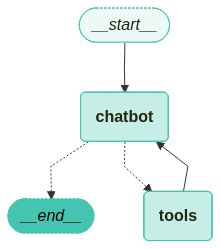

In [21]:
# 그래프 시각화
visualize_graph(graph_with_tools)

### 도구 사용 테스트

Tavily 검색 도구를 활용하여 최신 정보를 검색하는 테스트를 수행합니다. LLM이 질문에 답하기 위해 필요하다고 판단하면 자동으로 검색 도구를 호출합니다.

아래 코드는 2025년 LangGraph 사용 사례에 대한 검색을 수행합니다.

In [ ]:
from langchain_teddynote.messages import stream_graph

stream_graph(
    graph_with_tools,
    inputs={
        "messages": [HumanMessage(content="2025년 LangGraph 사용 사례 알려주세요.")]
    },
    config=config,
)

---

## 메모리 추가

세션 간 사용자 정보를 유지하는 영구 상태 관리를 추가합니다. 메모리 기능을 통해 챗봇이 이전 대화 내용을 기억하고, 사용자별로 개인화된 응답을 제공할 수 있습니다.

> 📖 **참고 문서**: [LangGraph Persistence](https://docs.langchain.com/oss/python/langgraph/persistence.md)

- 단기기억 : 세션 한정
- 장기기억 : 계정 단위

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Checkpointer | 그래프 실행 중 상태를 저장하고 복원하는 컴포넌트 |
| Thread ID | 동일 세션을 식별하는 고유 식별자 |
| User ID | 사용자별 장기 기억을 관리하는 식별자 |
| Persistent State | 누적된 대화 이력 기반의 컨텍스트 |

아래 코드는 메모리 추출을 위한 Pydantic 모델과 추출기를 정의합니다.

In [23]:
from typing import List, Optional
from datetime import datetime
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import PydanticOutputParser
import os


# Pydantic 모델 정의
class MemoryItem(BaseModel):
    """개별 메모리 아이템"""

    key: str = Field(description="메모리 키 (예: user_name, preference, fact)")
    value: str = Field(description="메모리 값")
    category: str = Field(
        description="카테고리 (personal_info, preference, interest, relationship, fact, etc.)"
    )
    importance: int = Field(description="중요도 (1-5, 5가 가장 중요)", ge=1, le=5)
    confidence: float = Field(description="추출 신뢰도 (0.0-1.0)", ge=0.0, le=1.0)


class ExtractedMemories(BaseModel):
    """추출된 메모리 컬렉션"""

    memories: List[MemoryItem] = Field(description="추출된 메모리 아이템 리스트")
    summary: str = Field(description="대화 내용 요약")
    timestamp: str = Field(
        default_factory=lambda: datetime.now().isoformat(), description="추출 시간"
    )


# 기본 시스템 프롬프트
DEFAULT_SYSTEM_PROMPT = """You are an expert memory extraction assistant. Your task is to extract important information from user conversations and convert them into structured key-value pairs for long-term memory storage.

Extract ALL relevant information from the conversation, including:
- Personal information (name, age, location, occupation, etc.)
- Preferences and interests
- Relationships and social connections
- Important facts or events mentioned
- Opinions and beliefs
- Goals and aspirations
- Any other notable information

For each piece of information:
1. Create a concise, searchable key
2. Store the complete value
3. Categorize appropriately
4. Assess importance (1-5 scale)
5. Evaluate extraction confidence (0.0-1.0)"""


def create_memory_extractor(
    model_name: Optional[str] = "anthropic:claude-sonnet-4-5",
    system_prompt: Optional[str] = None,
) -> any:
    """메모리 추출기를 생성합니다.

    Args:
        model: 사용할 언어 모델. None일 경우 기본 ChatOpenAI 모델 사용
        system_prompt: 시스템 프롬프트. None일 경우 기본 프롬프트 사용

    Returns:
        메모리 추출 체인
    """
    # Output Parser 생성
    memory_parser = PydanticOutputParser(pydantic_object=ExtractedMemories)

    # 시스템 프롬프트 설정
    if system_prompt is None:
        system_prompt = DEFAULT_SYSTEM_PROMPT

    # 전체 프롬프트 템플릿 구성
    template = f"""{system_prompt}

User Input: {{input}}

{{format_instructions}}

Remember to:
- Extract multiple memory items if the conversation contains various pieces of information
- Use clear, consistent key naming conventions
- Preserve context in values when necessary
- Be comprehensive but avoid redundancy
"""

    # 프롬프트 생성
    prompt = ChatPromptTemplate.from_template(
        template,
        partial_variables={
            "format_instructions": memory_parser.get_format_instructions()
        },
    )

    # 모델 설정
    model = init_chat_model(model_name)

    # 메모리 추출 체인 생성
    memory_extractor = prompt | model | memory_parser

    return memory_extractor

In [25]:
memory_parser = PydanticOutputParser(pydantic_object=ExtractedMemories)
memory_parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"$defs": {"MemoryItem": {"description": "개별 메모리 아이템", "properties": {"key": {"description": "메모리 키 (예: user_name, preference, fact)", "title": "Key", "type": "string"}, "value": {"description": "메모리 값", "title": "Value", "type": "string"}, "category": {"description": "카테고리 (personal_info, preference, interest, relationship, fact, etc.)", "title": "Category", "type": "string"}, "importance": {"description": "중요도 (1-5, 5가 가장 중요)", "maximum": 5, "minimum": 1, "title": "Importance", "type": "integer"}, "confidence": {"description": "추출 신뢰

In [27]:
from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.store.base import BaseStore
from langchain_openai import ChatOpenAI

from langchain_teddynote.memory import create_memory_extractor
import uuid

model = init_chat_model("anthropic:claude-sonnet-4-5")
memory_extractor = create_memory_extractor(model="anthropic:claude-sonnet-4-5")


def call_model(
    state: MessagesState,
    config: RunnableConfig,
    *,
    store: BaseStore,
) -> dict[str, Any]:
    """LLM 모델을 호출하고 사용자 메모리를 관리합니다.

    Args:
        state (MessagesState): 메시지를 포함하는 현재 상태
        config (RunnableConfig): 실행 가능 구성
        store (BaseStore): 메모리 저장소
    """
    # 마지막 메시지에서 user_id 추출
    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id)

    print(namespace)

    # 유저의 메모리 검색(의미검색)
    memories = store.search(namespace, query=str(state["messages"][-1].content))
    info = "\n".join([f"{memory.key}: {memory.value}" for memory in memories])
    system_msg = f"You are a helpful assistant talking to the user. User info: {info}"

    # 사용자가 기억 요청 시 메모리 저장
    last_message = state["messages"][-1]
    if "remember" in last_message.content.lower():
        result = memory_extractor.invoke({"input": str(state["messages"][-1].content)})
        for memory in result.memories:
            print(memory)
            print("-" * 100)
            store.put(namespace, str(uuid.uuid4()), {memory.key: memory.value})

    # LLM 호출
    response = model.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )
    return {"messages": response}

In [28]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

# 그래프 빌드
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

# 메모리 체크포인터 생성
# 실제 프로덕션에서는 PostgresSaver 사용 권장
memory_saver = InMemorySaver()
memory_store = InMemoryStore()

# 그래프 컴파일
graph_with_memory = builder.compile(
    checkpointer=memory_saver,
    store=memory_store,
)

In [29]:
from langchain_teddynote.messages import stream_graph


def run_graph(
    msg,
    thread_id="default",
    user_id="default",
):
    config = {
        "configurable": {
            "thread_id": thread_id + user_id,
            "user_id": user_id,
        }
    }
    print(f"\n[유저] {msg}")
    stream_graph(
        graph_with_memory,
        inputs={"messages": [{"role": "user", "content": msg}]},
        config=config,
    )
    print()

In [30]:
# 메시지, thread_id, user_id 전달
run_graph("안녕? 내 이름은 테디야", "1", "someone")


[유저] 안녕? 내 이름은 테디야
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕하세요, 테디님! 만나서 반가워요. 😊

무엇을 도와드릴까요? 궁금한 것이 있거나 이야기하고 싶은 주제가 있으면 편하게 말씀해 주세요!


In [31]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "1", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
당신의 이름은 테디라고 하셨어요! 😊


In [33]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고?", "2", "someone")


[유저] 내 이름이 뭐라고?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
죄송합니다만, 여전히 당신의 이름을 모릅니다. 이전 메시지에서도 말씀드렸듯이, 아직 이름을 알려주지 않으셨습니다.

혹시 제가 이미 알고 있어야 한다고 생각하시나요? 그렇다면 이전 대화 기록이 제게 전달되지 않았을 수 있습니다. 

다시 한 번 이름을 알려주시겠어요?


### 장기 기억 저장(계정 세팅)

메시지에 `remember` 키워드 포함 시 장기 저장소에 정보를 기록합니다.

In [34]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 테디야 remember", "2", "someone")


[유저] 내 이름이 테디야 remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "user_name",
      "value": "테디",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 자신의 이름이 '테디'라고 밝혔다.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='user_name' value='테디' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
알겠습니다, 테디님! 이제 기억했습니다. 

앞으로 테디님이라고 부르겠습니다. 무엇을 도와드릴까요?


### Thread 간 지속성

User ID 기반 장기 기억은 Thread가 달라도 유지됩니다.

In [35]:
# 메시지, thread_id, user_id 전달
run_graph("내 이름이 뭐라고 했더라?", "1004", "someone")


[유저] 내 이름이 뭐라고 했더라?
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
당신의 이름은 **테디**라고 하셨습니다! 😊


In [36]:
# 메시지, thread_id, user_id 전달
run_graph(
    "내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember", "4", "someone"
)


[유저] 내 직업은 AI Engineer 야. 내 취미는 Netflix 보기 야. remember
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "memories": [
    {
      "key": "occupation",
      "value": "AI Engineer",
      "category": "personal_info",
      "importance": 5,
      "confidence": 1.0
    },
    {
      "key": "hobby",
      "value": "Netflix 보기",
      "category": "interest",
      "importance": 4,
      "confidence": 1.0
    }
  ],
  "summary": "사용자는 자신의 직업이 AI Engineer이며, 취미는 Netflix 보기라고 밝혔다.",
  "timestamp": "2024-06-13T00:00:00Z"
}key='occupation' value='AI Engineer' category='personal_info' importance=5 confidence=1.0
----------------------------------------------------------------------------------------------------
key='hobby' value='Netflix 보기' category='interest' importance=4 confidence=1.0
----------------------------------------------------------------------------------------------------
안녕하세요, 테디님! 👋

네, 잘 기억하겠습니다! 

📌 **기억한 정보:**
- 직업: AI En

In [37]:
# 다른 스레드에서 실행
run_graph("내 이름, 직업, 취미 알려줘", "100", "someone")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'someone')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
당신에 대한 정보를 알려드리겠습니다:

- **이름**: 테디
- **직업**: AI Engineer (AI 엔지니어)
- **취미**: Netflix 보기

혹시 다른 궁금한 점이 있으신가요? 😊


In [38]:
# 다른 user_id 로 실행한 경우
run_graph("내 이름, 직업, 취미 알려줘", "100", "other")


[유저] 내 이름, 직업, 취미 알려줘
('memories', 'other')

🔄 Node: call_model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
죄송하지만, 저는 당신의 이름, 직업, 취미에 대한 정보를 가지고 있지 않습니다. 

우리의 대화는 지금 시작되었고, 당신에 대한 개인 정보를 제공받지 못했습니다. 제가 받은 정보는 토큰 예산(200,000)뿐입니다.

자기소개를 해주시면 더 도움이 될 것 같습니다! 😊


### State 확인

저장된 상태를 조회하여 메시지 이력과 체크포인트 정보를 확인합니다. `get_state` 메서드를 통해 현재 상태의 스냅샷을 가져올 수 있습니다.

아래 코드는 특정 Config에 대한 현재 상태 정보를 조회합니다.

In [39]:
# 임의의 Config 설정
config = {
    "configurable": {
        "thread_id": "100" + "someone",
        "user_id": "someone",
    }
}

# 현재 상태 가져오기
snapshot = graph_with_memory.get_state(config)

print("현재 상태 정보:")
print(f"- 메시지 수: {len(snapshot.values['messages'])}개")
print(f"- 체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")

# 최근 메시지 몇 개 표시
print("\n[최근 메시지]")
for msg in snapshot.values["messages"]:
    role = msg.type if hasattr(msg, "type") else "unknown"
    content = msg.content if hasattr(msg, "content") else str(msg)
    print(f"  [{role}]: {content}")

현재 상태 정보:
- 메시지 수: 2개
- 체크포인트 ID: 1f14dc17-448b-6e28-8001-975100831017

[최근 메시지]
  [human]: 내 이름, 직업, 취미 알려줘
  [ai]: 당신에 대한 정보를 알려드리겠습니다:

- **이름**: 테디
- **직업**: AI Engineer (AI 엔지니어)
- **취미**: Netflix 보기

혹시 다른 궁금한 점이 있으신가요? 😊


---

## Human-in-the-Loop

고위험 작업에 대해 인간 승인을 요청하는 흐름을 도입합니다. 중요한 결정이나 민감한 작업 수행 전에 사람의 확인을 받을 수 있어 AI 시스템의 안전성을 높입니다.

> 📖 **참고 문서**: [LangGraph Interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts.md)

### 핵심 개념

| 개념 | 설명 |
|------|------|
| interrupt | 그래프 실행을 일시정지하고 외부 입력을 대기 |
| Command | 승인/거부 후 재개 명령을 전달하는 객체 |
| Human Approval | 사람이 검토하고 승인하는 워크플로우 |

아래 코드는 사람의 도움을 요청하는 도구를 정의합니다.

In [45]:
from langchain_core.tools import tool
from langgraph.types import Command, interrupt


@tool
def human_assistance(query: str) -> str:
    """Request assistance from an expert(human)."""
    # interrupt를 호출하여 실행 일시 중지
    # 사람의 응답을 기다림
    human_response = interrupt({"query": query})

    print(human_response)

    # 사람의 응답 반환
    return human_response["data"]

### HITL 그래프 구성

`human_assistance` 도구를 사용하는 그래프를 구성합니다. 이 도구가 호출되면 `interrupt`로 실행이 중단되고, 사람의 응답을 기다립니다. 응답이 입력되면 해당 내용을 반환하여 대화를 계속합니다.

아래 코드는 Human-in-the-Loop 기능이 포함된 그래프를 구성합니다.

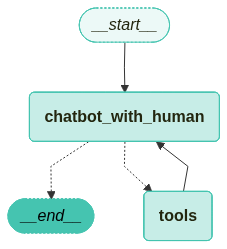

In [46]:
# 도구 리스트 업데이트
tools_with_human = [human_assistance]

# 새로운 그래프 구성
graph_builder_hitl = StateGraph(State)

# LLM에 도구 바인딩
llm_with_human_tools = llm.bind_tools(tools_with_human)


def chatbot_with_human(state: State):
    """Human Interuption 요청할 수 있는 챗봇"""
    message = llm_with_human_tools.invoke(state["messages"])

    # interrupt 중 병렬 도구 호출 방지
    # (재개 시 도구 호출이 반복되는 것을 방지)
    if hasattr(message, "tool_calls"):
        assert (
            len(message.tool_calls) <= 1
        ), "병렬 도구 호출은 interrupt와 함께 사용할 수 없습니다"

    return {"messages": [message]}


# 노드 추가
graph_builder_hitl.add_node("chatbot_with_human", chatbot_with_human)

# ToolNode 추가
tool_node_hitl = ToolNode(tools=tools_with_human)
graph_builder_hitl.add_node("tools", tool_node_hitl)

# 엣지 추가
graph_builder_hitl.add_conditional_edges("chatbot_with_human", tools_condition)
graph_builder_hitl.add_edge("tools", "chatbot_with_human")
graph_builder_hitl.add_edge(START, "chatbot_with_human")

# 메모리와 함께 컴파일
memory_hitl = InMemorySaver()
graph_hitl = graph_builder_hitl.compile(checkpointer=memory_hitl)

# 그래프 시각화
visualize_graph(graph_hitl)

### HITL 테스트

사람에게 조언을 요청하는 질문으로 interrupt와 재개 흐름을 검증합니다. 그래프가 중단되면 `get_state`로 현재 상태를 확인하고, `Command(resume=...)`로 재개할 수 있습니다.

아래 코드는 인간 지원을 요청하는 메시지로 그래프를 실행합니다.

In [47]:
from langchain_teddynote.messages import random_uuid

# 인간 지원을 요청하는 메시지
user_input = "LangGraph 가 뭐야? 사람한테 듣고 싶어."
config_hitl = {"configurable": {"thread_id": random_uuid()}}

print(f"User: {user_input}\n")

stream_graph(
    graph_hitl,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=config_hitl,
)

User: LangGraph 가 뭐야? 사람한테 듣고 싶어.


🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [44]:
# 상태 확인 - 어느 노드에서 중단되었는지 확인
snapshot = graph_hitl.get_state(config_hitl)

print(f"  다음 실행할 노드: {snapshot.next}")
print(f"  체크포인트 ID: {snapshot.config['configurable']['checkpoint_id']}")

  다음 실행할 노드: ('tools',)
  체크포인트 ID: 1f14dc6e-7f1d-67c4-8001-8e3781878ff2


In [48]:
# 인간의 응답으로 실행 재개
human_response = """## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)
"""

# Command 객체로 재개
human_command = Command(resume={"data": human_response})

print(f"\n사람의 응답: {human_response}\n")

# 재개
stream_graph(graph_hitl, inputs=human_command, config=config_hitl)


사람의 응답: ## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)


{'data': '## 전문가의 조언:\n- YouTube 테디노트: https://www.youtube.com/c/teddynote\n- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)\n'}

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
## 전문가의 조언:
- YouTube 테디노트: https://www.youtube.com/c/teddynote
- 고급 개발자 강의 [패스트캠퍼스 RAG 비법노트](https://fastcampus.co.kr/data_online_teddy)

🔄 Node: chatbot_with_human 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
전문가가 답변해주셨습니다! LangGraph에 대해 더 자세히 알고 싶으시다면 다음 리소스를 참고하실 수 있습니다:

1. **YouTube 테디노트**: https://www.youtube.com/c/teddynote
   - LangGraph 관련 영상들을 확인하실 수 있습니다.

2. **패스트캠퍼스 RAG 비법노트 강의**: https://fastcampus.co.kr/data_online_teddy
   - 고급 개발자를 위한 LangGraph 및 RAG 관련 심화 내용을 다룹니다.

간단히 설명드리자면, LangGraph는 LangChain에서 개발한 라이브러리로, **복잡한 AI 에이전트와 워크플로우를 그래프 구조로 구축**할 수 있게 해주는 도구입니다. 순환 구조, 상태 관리, 조건부 분기 등을 지원하여 더 정

---

## 상태 커스터마이징

메시지 외에 업무 데이터를 다루는 커스텀 상태와 도구 기반 상태 업데이트를 도입합니다. `Command` 객체를 사용하면 도구 실행 결과로 상태를 직접 갱신할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| Custom State Fields | messages 외에 추가 필드를 정의 |
| State Updates from Tools | 도구 결과로 상태를 직접 갱신 |
| Command(update=...) | 상태 업데이트를 지정하는 명령 객체 |

아래 코드는 `human_feedback` 필드가 추가된 커스텀 상태를 정의합니다.

In [49]:
from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId


# 확장된 State 정의
class CustomState(TypedDict):
    """커스텀 필드가 추가된 상태"""

    messages: Annotated[list, add_messages]
    human_feedback: str  # 사람의 피드백

### 상태 업데이트 도구

도구 실행 결과를 `Command(update=...)`로 상태에 반영합니다. 이 패턴을 사용하면 도구가 단순히 문자열을 반환하는 것이 아니라, 상태의 특정 필드를 직접 수정할 수 있습니다.

아래 코드는 인간 검토를 요청하고 피드백에 따라 상태를 업데이트하는 도구를 정의합니다.

In [50]:
@tool
def human_review(
    human_feedback, tool_call_id: Annotated[str, InjectedToolCallId]
) -> str:
    """Request human review for information."""
    # 인간에게 검토 요청
    human_response = interrupt(
        {"question": "이 정보가 맞나요?", "human_feedback": human_feedback}
    )

    feedback = human_response.get("human_feedback", "")

    if feedback.strip() == "":
        # 사용자가 AI 의 답변에 동의하는 경우
        return Command(
            update={
                "messages": [ToolMessage(human_response, tool_call_id=tool_call_id)]
            }
        )
    else:
        # 사용자가 AI 의 답변에 동의하지 않는 경우
        corrected_information = f"# 사용자에 의해 수정된 피드백: {feedback}"
        return Command(
            update={
                "messages": [
                    ToolMessage(corrected_information, tool_call_id=tool_call_id)
                ]
            }
        )

### 커스텀 상태 그래프

`CustomState`를 사용하여 그래프를 구성합니다. 기본 `State` 대신 커스텀 상태를 사용하면 애플리케이션에 필요한 추가 데이터를 관리할 수 있습니다.

아래 코드는 커스텀 상태와 `human_review` 도구를 사용하는 그래프를 구성합니다.

In [51]:
# 도구 리스트
tools_custom = [human_review]

# 새로운 그래프 구성
custom_graph_builder = StateGraph(CustomState)  # CustomState 사용

# LLM에 도구 바인딩
llm_with_custom_tools = llm.bind_tools(tools_custom)


def chatbot_custom(state: CustomState):
    """커스텀 상태를 사용하는 챗봇"""
    message = llm_with_custom_tools.invoke(state["messages"])

    if hasattr(message, "tool_calls"):
        assert len(message.tool_calls) <= 1

    return {"messages": [message]}


# 노드와 엣지 추가
custom_graph_builder.add_node("chatbot", chatbot_custom)
tool_node_custom = ToolNode(tools=tools_custom)
custom_graph_builder.add_node("tools", tool_node_custom)

custom_graph_builder.add_conditional_edges("chatbot", tools_condition)
custom_graph_builder.add_edge("tools", "chatbot")
custom_graph_builder.add_edge(START, "chatbot")

# 컴파일
memory_custom = InMemorySaver()
custom_graph = custom_graph_builder.compile(checkpointer=memory_custom)

### 그래프 시각화

커스텀 상태 그래프의 구조를 시각화합니다. 기본 도구 그래프와 동일한 구조이지만, 내부적으로 `CustomState`를 사용합니다.

아래 코드는 커스텀 상태 그래프를 시각화합니다.

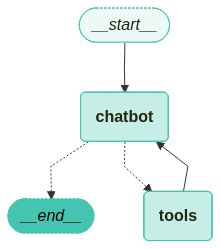

In [54]:
# 그래프 시각화
visualize_graph(custom_graph)

### 커스텀 상태 테스트

`human_review` 도구 호출 시 interrupt로 중단되고, 재개 시 사용자 피드백에 따라 상태가 갱신되는지 확인합니다. 사용자가 빈 피드백을 제공하면 AI의 답변에 동의하는 것으로 처리됩니다.

아래 코드는 인간 검토가 필요한 질문으로 그래프를 실행합니다.

In [52]:
# LangGraph의 출시일을 조사하고 검토 요청
user_input = (
    "2024년 노벨 문학상 수상자가 누구인지 조사해주세요. "
    "답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요."
)

custom_config = RunnableConfig(configurable={"thread_id": random_uuid()})

print(f"User: {user_input}\n")

# 실행 (interrupt에서 중단될 것임)
stream_graph(
    custom_graph,
    inputs={"messages": [HumanMessage(content=user_input)]},
    config=custom_config,
)

User: 2024년 노벨 문학상 수상자가 누구인지 조사해주세요. 답을 찾으면 `human_review` 도구를 사용해서 검토를 요청하세요.


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 


In [53]:
from langchain_teddynote.messages import display_message_tree

# 최신 메시지 가져오기
last_message = custom_graph.get_state(custom_config).values["messages"][-1]

# 최신 메시지 tree 구조로 표시
display_message_tree(last_message)

    content:
        index [0]
            id: "toolu_015CMArzWQgZduhBjp8hdbDR"
            caller: {"type": "direct"}
            input: {}
            name: "human_review"
            type: "tool_use"
            index: 0
            partial_json: "{"human_feedback": "2024년 노벨 문학상 수상자는 한강(Han Kang)입니다. \n\n한강은 한국의 소설가로, 1970년 광주에서 태어났으며 \"채식주의자\", \"소년이 온다\", \"흰\" 등의 작품으로 유명합니다. 그녀는 2024년 10월 10일에 노벨 문학상 수상자로 발표되었으며, \"강렬한 시적 산문으로 역사적 트라우마에 맞서고 인간 삶의 취약성을 드러낸 공로\"로 수상했습니다.\n\n한강은 아시아 여성 작가로는 최초로, 그리고 한국인으로는 최초로 노벨 문학상을 수상한 작가입니다.\n\n이 정보가 정확한지 검토 부탁드립니다."}"
    additional_kwargs: {}
    response_metadata: {"model_name": "claude-sonnet-4-5-20250929", "model_provider": "anthropic", "stop_reason": "tool_use", "stop_sequence": None}
    type: "ai"
    name: None
    id: "lc_run--019e1ae6-522a-7911-858d-ea7e68cf1ac4"
    tool_calls:
        index [0]
            name: "human_review"
            args: {"human_feedback": "2024년 노벨 문학상 수상자는 한강(Han Kang)입니다. 

한강은 한국의 소설가로, 1970년 광주에서 태어났으며 

In [55]:
# AI 가 작성한 내용
print(last_message.tool_calls[0]["args"]["human_feedback"])


2024년 노벨 문학상 수상자는 한강(Han Kang)입니다. 

한강은 한국의 소설가로, 1970년 광주에서 태어났으며 "채식주의자", "소년이 온다", "흰" 등의 작품으로 유명합니다. 그녀는 2024년 10월 10일에 노벨 문학상 수상자로 발표되었으며, "강렬한 시적 산문으로 역사적 트라우마에 맞서고 인간 삶의 취약성을 드러낸 공로"로 수상했습니다.

한강은 아시아 여성 작가로는 최초로, 그리고 한국인으로는 최초로 노벨 문학상을 수상한 작가입니다.

이 정보가 정확한지 검토 부탁드립니다.


In [56]:
# 인간의 검토 응답으로 재개
human_command = Command(
    resume={"human_feedback": "2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다."}
)

stream_graph(custom_graph, inputs=human_command, config=custom_config)


🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
# 사용자에 의해 수정된 피드백: 2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다.
🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
검토 결과 확인되었습니다! 

**2024년 노벨 문학상 수상자는 대한민국의 한강 작가입니다.**

한강 작가는 한국인 최초이자 아시아 여성 작가 최초로 노벨 문학상을 수상하는 역사적인 기록을 세웠습니다. 그녀의 대표작으로는 『채식주의자』, 『소년이 온다』, 『흰』 등이 있습니다.

---

## 상태 이력 관리

체크포인트 기반으로 상태를 저장/복원하여 롤백/재실행합니다. 이 기능을 통해 특정 시점으로 돌아가 다른 경로로 실행하거나, 실행 이력을 분석할 수 있습니다.

### 핵심 개념

| 개념 | 설명 |
|------|------|
| State History | 그래프 실행 중 발생한 모든 상태 변경 이력 |
| Checkpoint ID | 특정 시점의 상태를 식별하는 고유 ID |
| Rollback | 지정한 체크포인트로 상태를 복원 |
| Resume | 복원된 상태에서 실행을 재개 |

아래 섹션에서는 체크포인트 기반 상태 관리를 실습합니다.

### 체크포인트 기반 그래프 구성

상태 이력 확인과 롤백/재실행을 위한 그래프를 구성합니다. Tavily 검색 도구를 사용하여 여러 번의 대화를 수행하고, 각 단계의 상태를 저장합니다.

아래 코드는 체크포인터가 연결된 검색 그래프를 구성합니다.

In [88]:
# 상태 관리 테스트를 위한 체크포인트 기반 그래프
graph_builder = StateGraph(State)

# 도구와 LLM 설정
tools = [TavilySearch(max_results=2)]
llm_with_tools_tt = llm.bind_tools(tools)


def chatbot_tt(state: State):
    """상태 관리 테스트용 챗봇"""
    return {"messages": [llm_with_tools_tt.invoke(state["messages"])]}


# 그래프 구성
graph_builder.add_node("chatbot", chatbot_tt)
tool_node_tt = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node_tt)

graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# 메모리와 함께 컴파일
memory_tt = InMemorySaver()
time_travel_graph = graph_builder.compile(checkpointer=memory_tt)

### 그래프 시각화

체크포인트 기반 그래프의 구조를 확인합니다. 이전에 구성한 도구 그래프와 동일한 구조입니다.

아래 코드는 그래프를 시각화합니다.

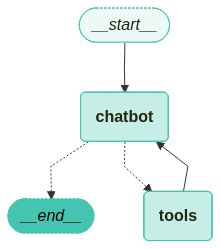

In [58]:
# 시각화
visualize_graph(time_travel_graph)

### 체크포인트 시퀀스 생성

여러 번 대화를 실행하여 상태 이력을 생성합니다. 각 실행마다 새로운 체크포인트가 생성되어 나중에 특정 시점으로 롤백할 수 있습니다.

아래 코드는 첫 번째 검색 대화를 실행합니다.

In [89]:
time_travel_config = RunnableConfig(configurable={"thread_id": "time-travel-30"})

# 첫 번째 대화
stream_graph(
    time_travel_graph,
    inputs={"messages": [HumanMessage(content="테디노트에 대해서 조사 좀 해주세요.")]},
    config=time_travel_config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "테디노트", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://wikidocs.net/profile/info/book/10226", "title": "테디노트 - 위키독스", "content": "### 테디노트\n\n한줄 소개\n:   블로그와 유튜브 \"테디노트\"를 운영하고 있으며, \"파이썬 딥러닝 텐서플로\"를 집필하였습니다. 데이터분석과 AI를 사랑하고 지식공유에 활발히 참여하고 있습니다.\n\n첫번째 컴퓨터\n:   기억이 안나요.\n\n블로그\n:   테디노트\n\n나의 URL\n:   \n\n 저서\n 최근댓글\n 최근수정\n 최근블로그\n\n<랭체인LangChain 노트> - LangChain 한국어 튜토리얼🇰🇷\n\n저자: 테디노트\n\n\\\\추천\\\\은 공유할 수 있는 무료 전자책을 집필하는데 정말 큰 힘이 됩니다. \\\\\"추천\"\\\\ 한 번씩만 부탁 드리겠습니다🙏🙏 ✅ \\\\랭체인 한국어 튜토리얼 강의\\\\ 패스트캠퍼스 - RAG ✅ \\\\랭체인 한국어 튜토리얼 코드저장소(GitHub)\\\\ 📘🖥️ ✅ \\\\유튜브 \"테디노트\"\\…\n\n수정: 2025년 4월 30일 8:06 오후\n\n[한 권으로 끝내는 <판다스 노트>\n\n저자: 테디노트, Min\n\n판다스는 파이썬에서 가장 널리 쓰이는 라이브러리 가운데 하나입니다. 데이터 분석 전문가가 파이썬으로 데이터 분석을 한다면, 아마 대부분은 가장 먼저 판다스 라이브러리를 임포트할 것입니다. 데이터 분석을 위한 필수 요소로 널리 자리잡은 판다스, 여러분이 파이썬의 기초를 충분히 학습했다면…\n\n수

In [90]:
# 두 번째 대화
stream_graph(
    time_travel_graph,
    inputs={
        "messages": [HumanMessage(content="메이플 플래닛이 뭐야?")]
    },
    config=time_travel_config,
)


🔄 Node: chatbot 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "메이플 플래닛", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://namu.wiki/w/%EB%A9%94%EC%9D%B4%ED%94%8C%20%ED%94%8C%EB%9E%98%EB%8B%9B", "title": "메이플 플래닛 - 나무위키", "content": "|  |\n\n| 메이플 플래닛 MAPLE PLANET |\n| 개발 | 메이플플래닛(#fn-1 \"2인 개발로 알려져있다. #\") |\n| 플랫폼 | Microsoft Windows | Android | iOS |\n| 장르 | 2D 횡스크롤 RPG |\n| 출시일 | 클로즈 베타(1차) 2025년 12월 10일(#fn-2 \"12월 10일 오후 8시 30분부터 12월 14일 오후 11시 59분까지 약 4일간 진행되었다.\") 클로즈 베타(2차) 2026년 1월 13일(#fn-3 \"1월 13일 오후 8시부터 4월 20일 오전 12시까지 약 3개월간 진행되었다.\") 오픈 베타 2026년 4월 24일(#fn-4 \"4월 24일 오후 8시부터 현재까지 진행되고 있다.\") |\n| 최대 플레이어 | 80명 (메인 서버) 50명 (원정대) |\n| 관련 사이트 | maplestoryworlds 홈페이지 아이콘 유튜브 아이콘 디스코드 아이콘 |\n\n1. 개요2. 특징3. 게임 요소\n\n3.1. 지역3.2. 직업\n\n4. 업데이트 내역5. 평가\n\n5.1. 긍정적 평가5.2. 부정적 평가5.3. 복합적 평가5.4. 총평\n\n6. 흥행7. 기타8. 관련 문서9. 외부 링크\n\n## 1. 개요(/edit/%EB%A9%94%EC%

### 상태 이력 탐색

`get_state_history`로 전체 상태 이력을 조회하고 롤백할 체크포인트를 선택합니다. 이력은 최신순으로 반환되며, 각 체크포인트에는 해당 시점의 상태 정보가 포함됩니다.

아래 코드는 상태 이력을 조회하고 특정 조건(메시지 수가 6개)에 해당하는 체크포인트를 선택합니다.

In [91]:
# 전체 상태 히스토리 확인
print("상태 히스토리 (최신순):")
print("=" * 80)

# to_replay 변수 초기화
to_replay = None

for i, state in enumerate(time_travel_graph.get_state_history(time_travel_config)):
    print(f"\n[체크포인트 {i}]")
    print(f"  다음 노드: {state.next}")
    print(f"  체크포인트 ID: {state.config['configurable']['checkpoint_id']}")

    if len(state.values["messages"]) == 6 and to_replay is None:
        print("  이 상태로 되돌아갈 예정")
        display_message_tree(state.values["messages"][-1])
        to_replay = state


print("\n" + "=" * 80)

상태 히스토리 (최신순):

[체크포인트 0]
  다음 노드: ()
  체크포인트 ID: 1f14dd3e-f915-6e48-8008-59e416671928

[체크포인트 1]
  다음 노드: ('chatbot',)
  체크포인트 ID: 1f14dd3e-5c06-6422-8007-5a74caec48c5

[체크포인트 2]
  다음 노드: ('tools',)
  체크포인트 ID: 1f14dd3e-54f2-6050-8006-c5540dd47269
  이 상태로 되돌아갈 예정
    content:
        index [0]
            id: "toolu_012RHQTYDkXfhkGgtZhMQjCc"
            caller: {"type": "direct"}
            input: {}
            name: "tavily_search"
            type: "tool_use"
            index: 0
            partial_json: "{"query": "메이플 플래닛", "search_depth": "advanced"}"
        index [1]
            id: "toolu_01AHFBGFQG4bTBzMW4ThmT4v"
            caller: {"type": "direct"}
            input: {}
            name: "tavily_search"
            type: "tool_use"
            index: 1
            partial_json: "{"query": "Maple Planet game", "search_depth": "advanced"}"
    additional_kwargs: {}
    response_metadata: {"model_name": "claude-sonnet-4-5-20250929", "model_provider": "anthropic", "stop_rea

### 체크포인트로 롤백

선택한 체크포인트의 상태를 확인합니다. 이 시점의 마지막 메시지 내용을 표시하여 어느 지점으로 돌아갈지 확인할 수 있습니다.

아래 코드는 선택한 체크포인트의 마지막 메시지를 표시합니다.

In [ ]:
display_message_tree(to_replay.values["messages"][-1])

In [95]:
to_replay.next

('tools',)

### 상태 수정

복원된 상태에서 도구 호출 파라미터를 수정합니다. `update_tool_call` 함수를 사용하면 기존 도구 호출의 인자를 변경할 수 있어, 다른 검색어로 재실행할 수 있습니다.

아래 코드는 Tavily 검색 도구의 쿼리를 수정합니다.

In [93]:
from langchain_teddynote.tools import update_tool_call

# 사용 예시:
updated_message = update_tool_call(
    to_replay.values["messages"][-1],
    tool_name="tavily_search",
    tool_args={"query": "로스트아크 site:naver.com", "search_depth": "basic"},
)

In [82]:
updated_message

AIMessage(content=[{'id': 'toolu_01NAx841iJWEuJg3zuen4phu', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'tavily_search', 'type': 'tool_use', 'index': 0, 'partial_json': '{"query": "메이플 플래닛", "search_depth": "advanced"}'}, {'id': 'toolu_01Bc5FjLwwKS7wXB9WM16fd8', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'tavily_search', 'type': 'tool_use', 'index': 1, 'partial_json': '{"query": "Maple Planet game", "search_depth": "advanced"}'}], additional_kwargs={}, response_metadata={'model_name': 'claude-sonnet-4-5-20250929', 'model_provider': 'anthropic', 'stop_reason': 'tool_use', 'stop_sequence': None}, id='lc_run--019e1b0b-3fb4-71e2-8ddf-41dcfb0b2b78', tool_calls=[{'name': 'tavily_search', 'args': {'query': '로스트아크 site:naver.com', 'search_depth': 'basic'}, 'id': 'toolu_01NAx841iJWEuJg3zuen4phu', 'type': 'tool_call'}, {'name': 'tavily_search', 'args': {'query': 'Maple Planet game', 'search_depth': 'advanced'}, 'id': 'toolu_01Bc5FjLwwKS7wXB9WM16fd8', 'type': 'tool_call'}], invalid

In [ ]:
# 변경하기 전의 message
display_message_tree(to_replay.values["messages"][-1])

In [ ]:
# 변경한 이후의 메시지 트리
display_message_tree(updated_message)

In [97]:
# 변경된 메시지를 update_state 로 업데이트
updated_state = time_travel_graph.update_state(
    values={"messages": [updated_message]}, config=to_replay.config
)

In [98]:
updated_state

{'configurable': {'thread_id': 'time-travel-30',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14dd42-9553-6302-8007-2fa1b937485a'}}

### 수정 상태 재실행

업데이트된 상태로 그래프를 재실행하여 결과를 확인합니다. `update_state` 메서드로 상태를 수정하면 해당 시점부터 새로운 경로로 실행이 계속됩니다.

아래 코드는 수정된 검색 쿼리로 그래프를 재실행합니다.

In [99]:
# 업데이트된 메시지를 스트리밍 합니다.
stream_graph(time_travel_graph, inputs=None, config=updated_state)


🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "로스트아크", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://mkt.shopping.naver.com/link/69cb555e5b90fc2ac7c6fc96", "title": "로스트아크 - NAVER", "content": "로스트아크 스토어.", "score": 0.9999286, "raw_content": null}, {"url": "https://m.blog.naver.com/PostView.naver?blogId=rudenchel&logNo=222275412269", "title": "[로스트아크] 로스트아크 첫 시작 - 네이버 블로그 - NAVER", "content": "내 게임 인생은 그러했다. 처음으로 접한 게임은 우리나라 대표적 MMORPG 「바람의 나라」를 기점으로 「포트리스」, 「얍카」, 「귀혼」, 「그랜드체이스", "score": 0.99991584, "raw_content": null}], "response_time": 0.72, "request_id": "67932340-cefc-46c0-a8f3-6d05fa4f207e"}{"query": "Maple Planet game", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.namu.wiki/w/%EB%A9%94%EC%9D%B4%ED%94%8C%20%ED%94%8C%EB%9E%98%EB%8B%9B", "title": "maple planet - NamuWiki", "content": "|  |  |\n --- |\n| Maple planet MAPLE PLANET | |\n| File:Maple Plane...File:Map